# Statistical Analysis Notebook
**Goal**: Follow Demsar framework to provide fair and confident evaluation

## Build the per fold matrix

In [ ]:
from pathlib import Path
import pandas as pd

PER_FOLD_CSV = Path("./results/adult_shortlist2.csv")  # <- change if different
if not PER_FOLD_CSV.exists():
    raise FileNotFoundError(f"Per-fold CSV not found: {PER_FOLD_CSV}")

df = pd.read_csv(PER_FOLD_CSV)

# required columns
need = [
   "metric","k","vote","retention",
    "fold_id","num_folds",
    "f1_macro"
]
missing = [c for c in need if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# build config_ids
metric_code = {"euclidean": "e", "cosine": "c", "heom": "h"}
vote_code   = {"borda": "b", "modified_plurality": "mp"}
ret_code    = {
    "RetentionPolicy.ALWAYS_RETAIN": "AR",
    "RetentionPolicy.NEVER_RETAIN": "NR",
    "RetentionPolicy.DIFFERENT_CLASS_RETENTION": "DC",
    "RetentionPolicy.DD_RETENTION": "DD",
}

def short_config_id(row):
    m = metric_code.get(str(row["metric"]), str(row["metric"])[:2])
    v = vote_code.get(str(row["vote"]), str(row["vote"])[:2])
    r = ret_code.get(str(row["retention"]), str(row["retention"])[:2])
    return f"{m}-k{int(row['k'])}-{v}-{r}"

if "config_id" not in df.columns:
    df["config_id"] = df.apply(short_config_id, axis=1)

df
# Build the pivot matrix
pivot = df.pivot_table(index="fold_id", columns="config_id", values="f1_macro", aggfunc="mean")
pivot


config_id,c-k3-mp-AR,c-k5-b-AR,c-k5-mp-AR,c-k7-b-AR,c-k7-b-DC,c-k7-b-DD,c-k7-b-NR,c-k7-mp-DD,e-k3-b-DC,e-k5-mp-AR,e-k7-b-AR,e-k7-b-DD,e-k7-mp-DC,e-k7-mp-DD,e-k7-mp-NR,h-k7-b-DD,h-k7-mp-AR,h-k7-mp-DC,h-k7-mp-DD,h-k7-mp-NR
fold_id,,,,,,,,,,,,,,,,,,,,
0,0.670954,0.683027,0.682795,0.677965,0.675566,0.677151,0.669946,0.673093,0.661527,0.655626,0.660998,0.661877,0.646797,0.646921,0.645281,0.661229,0.645218,0.645913,0.646921,0.644775
1,0.684188,0.678815,0.683730,0.686329,0.685182,0.686975,0.685153,0.688102,0.647843,0.644495,0.653958,0.654441,0.644313,0.643190,0.638926,0.653988,0.644002,0.644379,0.643879,0.639802
2,0.689085,0.694547,0.691857,0.694145,0.694539,0.694551,0.697145,0.688412,0.648640,0.650804,0.661054,0.659340,0.644711,0.644504,0.643529,0.659528,0.643636,0.644035,0.643329,0.643031
3,0.677279,0.687837,0.679205,0.684417,0.683967,0.684387,0.680886,0.686999,0.650778,0.644925,0.653197,0.653306,0.642015,0.642015,0.641831,0.652139,0.642389,0.642202,0.641892,0.642018
4,0.685453,0.686918,0.683174,0.691730,0.692005,0.690881,0.692428,0.680928,0.660373,0.638214,0.646412,0.646780,0.637126,0.635885,0.637275,0.646510,0.635560,0.636113,0.635560,0.636951
5,0.662448,0.670123,0.678252,0.674925,0.675483,0.674732,0.675784,0.676324,0.636848,0.647875,0.644671,0.646966,0.633047,0.634989,0.631183,0.646782,0.635869,0.633231,0.634989,0.631367
6,0.691474,0.692724,0.685512,0.693818,0.693241,0.694625,0.691795,0.687721,0.653957,0.644642,0.654240,0.653818,0.640402,0.641209,0.641458,0.653365,0.640712,0.640216,0.641209,0.641458
7,0.688710,0.692420,0.697464,0.695236,0.695490,0.695018,0.692350,0.688202,0.650348,0.649764,0.655968,0.656456,0.648146,0.647458,0.645977,0.654755,0.646959,0.648526,0.647458,0.646167
8,0.679277,0.686386,0.679346,0.681883,0.683810,0.683090,0.682860,0.683652,0.657556,0.649390,0.665089,0.665079,0.644264,0.644264,0.644147,0.664436,0.643953,0.644264,0.644264,0.644147


In [2]:
# rank within each fold
ranks = pivot.rank(axis=1, ascending=False, method="average")  # ties get average rank

# aggregate across folds
avg_rank = ranks.mean(axis=0)                 # average rank per config
mean_f1  = pivot.mean(axis=0)                 # mean F1 across folds 
std_f1   = pivot.std(axis=0, ddof=1)          # spread across folds
rank1_ct = (ranks == 1.0).sum(axis=0)         # how many times each config was rank 1

rank_table = (
    pd.DataFrame({
        "avg_rank": avg_rank,
        "mean_f1":  mean_f1,
        "std_f1":   std_f1,
        "rank1_count": rank1_ct,
    })
    .sort_values(["avg_rank","mean_f1"], ascending=[True, False])
)
rank_table

,avg_rank,mean_f1,std_f1,rank1_count
config_id,,,,
c-k7-b-AR,3.40,0.685971,0.007437,1
c-k7-b-DC,3.40,0.685764,0.007735,0
c-k7-b-DD,3.50,0.685926,0.007720,1
c-k5-b-AR,4.00,0.684830,0.007979,3
c-k7-b-NR,4.20,0.684738,0.008634,2
c-k5-mp-AR,5.20,0.683534,0.006855,2
c-k7-mp-DD,5.30,0.682161,0.007310,1
c-k3-mp-AR,7.00,0.679899,0.009618,0
e-k7-b-DD,9.90,0.654036,0.007138,0


In [3]:
from scipy.stats import friedmanchisquare

pivot_f = pivot.dropna(axis=1, how="any")
alg_vectors = [pivot_f[c].values for c in pivot_f.columns]

stat, pval = friedmanchisquare(*alg_vectors)
print(f"Friedman test = {stat:.4f}, p = {pval:.6g}  (df = {pivot_f.shape[1]-1})")

Friedman test = 171.6524, p = 1.34897e-26  (df = 19)


In [4]:
import numpy as np
import pandas as pd
import scikit_posthocs as sp

# Drop any columns with NaN 
pivot_n = pivot.dropna(axis=1, how="any")

# Nemenyi posthoc on Friedman ranks
nemenyi_p = sp.posthoc_nemenyi_friedman(pivot_n.values)

# Add config labels to the matrix 
nemenyi_p.index = pivot_n.columns
nemenyi_p.columns = pivot_n.columns
    
print("Nemenyi post-hoc p-values (all vs all):")
display(nemenyi_p.round(4))

Nemenyi post-hoc p-values (all vs all):


config_id,c-k3-mp-AR,c-k5-b-AR,c-k5-mp-AR,c-k7-b-AR,c-k7-b-DC,c-k7-b-DD,c-k7-b-NR,c-k7-mp-DD,e-k3-b-DC,e-k5-mp-AR,e-k7-b-AR,e-k7-b-DD,e-k7-mp-DC,e-k7-mp-DD,e-k7-mp-NR,h-k7-b-DD,h-k7-mp-AR,h-k7-mp-DC,h-k7-mp-DD,h-k7-mp-NR
config_id,,,,,,,,,,,,,,,,,,,,
c-k3-mp-AR,1.0000,0.9999,1.0000,0.9986,0.9986,0.9990,1.0000,1.0000,0.9904,0.7309,0.9986,0.9999,0.0657,0.0739,0.0032,0.9972,0.0207,0.0619,0.0354,0.0051
c-k5-b-AR,0.9999,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.4120,0.0697,0.5881,0.7820,0.0008,0.0009,0.0000,0.5284,0.0001,0.0007,0.0003,0.0000
c-k5-mp-AR,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.7571,0.2390,0.8858,0.9675,0.0056,0.0065,0.0001,0.8488,0.0013,0.0051,0.0025,0.0002
c-k7-b-AR,0.9986,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.2605,0.0331,0.4120,0.6178,0.0003,0.0003,0.0000,0.3576,0.0000,0.0002,0.0001,0.0000
c-k7-b-DC,0.9986,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.2605,0.0331,0.4120,0.6178,0.0003,0.0003,0.0000,0.3576,0.0000,0.0002,0.0001,0.0000
c-k7-b-DD,0.9990,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.2832,0.0377,0.4404,0.6470,0.0003,0.0004,0.0000,0.3844,0.0001,0.0003,0.0001,0.0000
c-k7-b-NR,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.4693,0.0877,0.6470,0.8280,0.0011,0.0013,0.0000,0.5881,0.0002,0.0010,0.0004,0.0000
c-k7-mp-DD,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.7820,0.2605,0.9019,0.9739,0.0065,0.0075,0.0002,0.8681,0.0015,0.0060,0.0029,0.0003
e-k3-b-DC,0.9904,0.4120,0.7571,0.2605,0.2605,0.2832,0.4693,0.7820,1.0000,1.0000,1.0000,1.0000,0.9463,0.9557,0.4404,1.0000,0.7940,0.9410,0.8771,0.5284


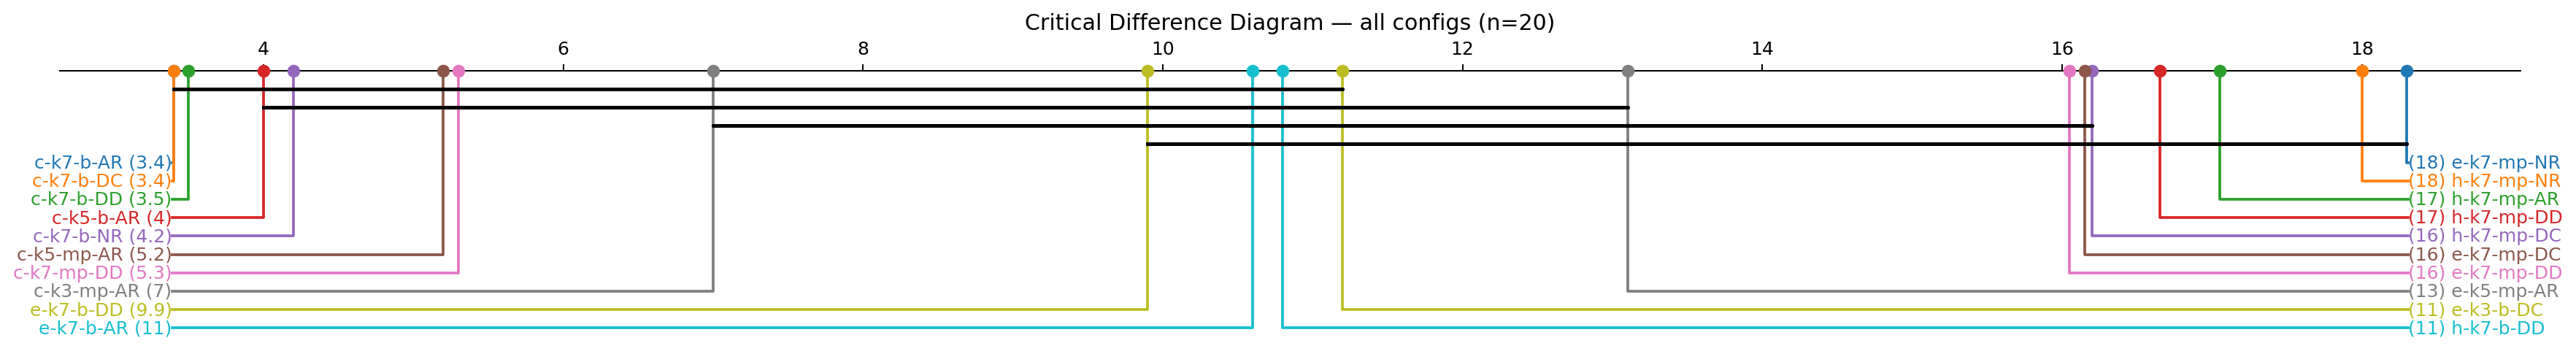

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scikit_posthocs as sp

# 1) Average ranks for all surviving configs (higher metric -> lower rank is better)
avg_ranks_all = pivot_n.rank(axis=1, ascending=False, method="average").mean()

# 2) Sort by average rank for display (best → worst)
order = avg_ranks_all.sort_values().index
avg_ranks = avg_ranks_all.loc[order]

# 3) Align the precomputed Nemenyi p-matrix to the same order
#    (you computed `nemenyi_p` earlier on pivot_n.values)
nemenyi_ordered = nemenyi_p.loc[order, order]

# 4) Plot
width = max(20, 0.45 * len(order))  # widen for many labels
plt.figure(figsize=(width, 2.8), dpi=180)
sp.critical_difference_diagram(avg_ranks, nemenyi_ordered)
plt.title(f"Critical Difference Diagram — all configs (n={len(order)})")
plt.tight_layout()
plt.show()